In [ ]:
# config.py
import torch
import os
import matplotlib.pyplot as plt
from PIL import Image

# --- Training Hyperparameters ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE_GEN = 1e-4
LEARNING_RATE_DISC = 1e-4
BATCH_SIZE = 16
NUM_EPOCHS_PRETRAIN = 50
NUM_EPOCHS_GAN = 100
HIGH_RES_SIZE = 96  # As per the paper
LOW_RES_SIZE = HIGH_RES_SIZE // 4
NUM_WORKERS = 4
LAMBDA_VGG = 1.0  # Weight for VGG/content loss
LAMBDA_ADV = 1e-3  # Weight for adversarial loss

os.makedirs("saved_models", exist_ok=True)

# --- Model Paths ---
PRETRAINED_GEN_PATH = "saved_models/srresnet_pretrained.pth"
GEN_PATH = "saved_models/generator.pth"
DISC_PATH = "saved_models/discriminator.pth"

# --- Dataset Paths ---
TRAIN_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_train_HR"
TEST_DIR = "/root/.cache/kagglehub/datasets/takihasan/div2k-dataset-for-super-resolution/versions/1/Dataset/DIV2K_valid_HR"

# set the repo name
model_name = "keanteng/srgan-div2k-0723-v2"

# Study 
## From The Paper
```
We
increase the resolution of the input image with two trained
sub-pixel convolution layers as proposed by Shi et al. [48].
```
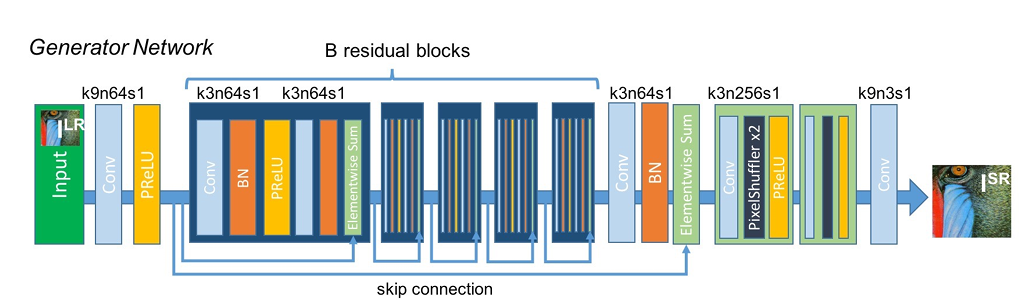

### What Are We Looking At?
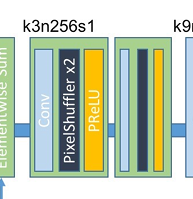

### What is PixelShuffle?
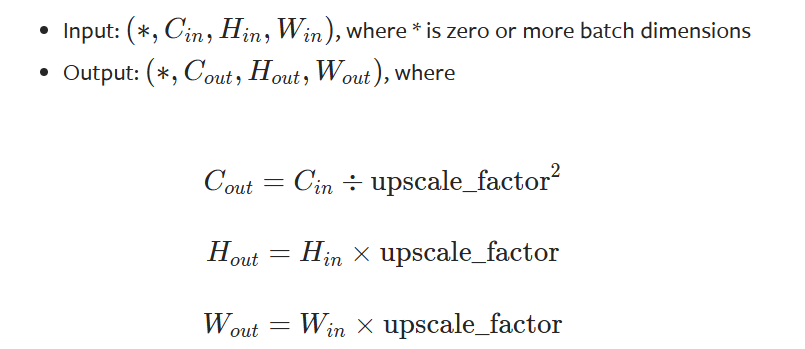

- Rearrabge elements in a tensor according to upscaling factor
- In our example of 2 channels and 4 upscale factor, the input tensor is reshaped to a 2x2 grid of 4 channels.
- Initially after Conv2d, c = 2 * 4 = 8, then afer PixelShuffle, c = 8 / 2^2 = 2.

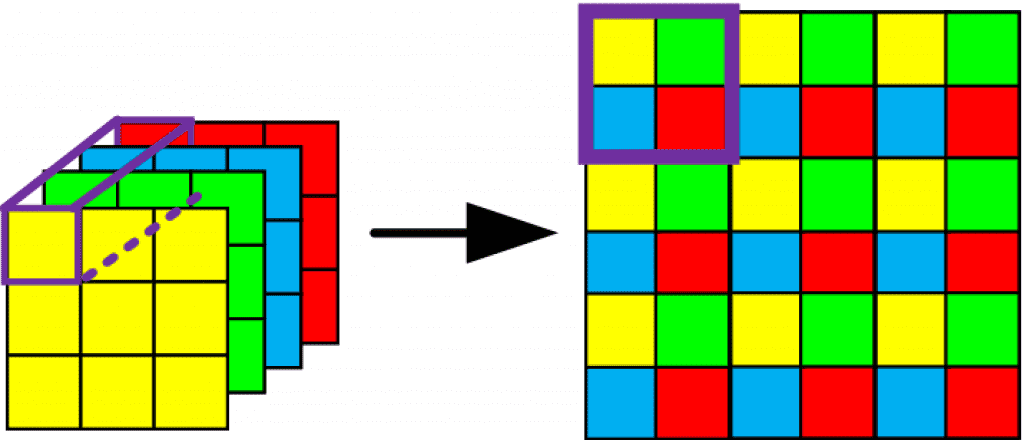

## Check The Conv Layer

In [7]:
from torch import nn
import torch

class UpsampleBlock(nn.Module):
    """
    Upsampling block using a convolutional layer and PixelShuffle.
    This increases the resolution by a factor of 2.
    """
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), kernel_size=3, stride=1, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
        self.prelu = nn.PReLU()

    # Go through conv, then pixel shuffle, then prelu
    def forward(self, x):
        return self.prelu(self.pixel_shuffle(self.conv(x)))

In [4]:
in_channels = 2  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = UpsampleBlock(in_channels)

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 2, 3, 3])
Input: tensor([[[[-0.3899, -0.4321,  0.0395],
          [-3.3061, -0.5800,  2.3565],
          [ 1.7454,  1.7552,  0.4113]],

         [[ 1.3702,  0.0185, -0.5144],
          [-0.5306,  0.1331, -1.3021],
          [-0.5972,  1.9030, -0.7614]]]])
Output shape: torch.Size([1, 2, 6, 6])
Output: tensor([[[[-0.1843,  0.2396,  0.7030,  0.1226,  0.4656,  0.3096],
          [ 0.6181,  0.4945,  0.0036,  0.4899, -0.1462, -0.0732],
          [ 0.7843, -0.1240, -0.1698,  0.1345, -0.1797, -0.0941],
          [-0.0112, -0.0221, -0.1450, -0.4931, -0.1806, -0.1390],
          [-0.2521,  1.2199,  0.1095,  0.7289,  0.9038, -0.0036],
          [-0.0667, -0.1684, -0.0163, -0.0453, -0.2273,  0.5809]],

         [[-0.0603,  0.2539, -0.0818, -0.0078,  0.3677, -0.0654],
          [ 1.1144,  0.1096, -0.0471, -0.1214, -0.0904, -0.0241],
          [-0.0214, -0.0712,  0.8123, -0.2505, -0.1168, -0.0486],
          [-0.2735, -0.1015, -0.0817,  0.3000,  0.0793, -0.0862],
       

## Check The Conv Layer

We can see the number of channels is multiplied by 4
We increase the number of features maps extracted by that layer

In [5]:
from torch import nn
import torch

class UpsampleBlock(nn.Module):
    """
    Upsampling block using a convolutional layer and PixelShuffle.
    This increases the resolution by a factor of 2.
    """
    def __init__(self, in_channels, scale_factor=2):
        super(UpsampleBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, in_channels * (scale_factor ** 2), kernel_size=3, stride=1, padding=1)
        self.prelu = nn.PReLU()

    def forward(self, x):
        return self.prelu(self.conv(x))

In [6]:
in_channels = 2  # Number of input channels
batch_size = 1  # Number of samples in a batch
height = 3  # Height of the input feature map
width = 3  # Width of the input feature map

# Create an instance of the model
model = UpsampleBlock(in_channels)

# Create a dummy input tensor
# Shape: (batch_size, in_channels, height, width)
dummy_input = torch.randn(batch_size, in_channels, height, width)

print(f"Input shape: {dummy_input.shape}")
print(f"Input: {dummy_input}")

# Pass the input through the conv_block1
output = model(dummy_input)

print(f"Output shape: {output.shape}")
print(f"Output: {output}")

Input shape: torch.Size([1, 2, 3, 3])
Input: tensor([[[[-0.3199, -1.4902, -1.7652],
          [ 1.1613, -0.9780,  0.5098],
          [ 0.5975,  0.0035, -0.8660]],

         [[ 0.0515, -0.1343, -2.5434],
          [ 0.2473,  0.1510,  0.2771],
          [ 0.3544, -0.0532, -0.1937]]]])
Output shape: torch.Size([1, 8, 3, 3])
Output: tensor([[[[-6.5079e-02,  1.4610e-01,  7.4336e-01],
          [-1.0607e-01, -1.1988e-03,  5.1444e-01],
          [-7.6878e-02,  1.5044e-01,  1.1689e-01]],

         [[ 1.6287e-01,  7.3514e-01,  2.0051e-02],
          [-2.7367e-02, -1.0091e-01, -4.7431e-02],
          [-2.1736e-02,  3.7833e-01,  2.2728e-02]],

         [[-1.4057e-01,  1.1971e-02,  4.6931e-01],
          [-4.8635e-02,  3.9263e-01, -1.4475e-02],
          [ 1.4497e-02,  3.3047e-01, -4.2800e-03]],

         [[-3.5820e-02, -2.1411e-01, -4.2760e-02],
          [ 4.9309e-02, -1.0013e-02,  6.6820e-01],
          [-3.7181e-02,  4.3978e-02, -9.0253e-02]],

         [[ 2.7068e-01,  6.5041e-01,  6.4531e-01]